[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/Guided_growth_BO_tutorial/blob/main/bayesian_optimization_device_growth.ipynb)

<div style="background:linear-gradient(135deg,#1E3A6E 70%,#2E5BAA);
            padding:44px 52px 40px;border-radius:14px;color:white;
            font-family:'Georgia',serif;">
  <div style="font-size:13px;letter-spacing:4px;color:#CFE0FA;
              font-family:'Trebuchet MS',sans-serif;margin-bottom:12px;">
    HANDS-ON TUTORIAL
  </div>
  <div style="font-size:38px;font-weight:bold;line-height:1.18;margin-bottom:16px;">
    Bayesian Optimization for<br>Epitaxial Device Growth
  </div>
  <div style="font-size:16px;color:#CFE0FA;font-family:'Trebuchet MS',sans-serif;
              line-height:1.65;margin-bottom:24px;">
    A self-contained, runnable notebook — no ML background needed.<br>
    Toy nanowire-like growth problem → DoE warm-start → single-objective BO →
    multi-objective BO → real InP/InAsP MQW microring laser pipeline.
  </div>
  <div style="background:rgba(255,255,255,0.13);border-radius:9px;
              padding:14px 20px;font-family:'Trebuchet MS',sans-serif;font-size:14px;">
    <b style="color:#E8643C;">▶ How to run</b><br>
    1 · Run <b>Section 0 (Setup)</b>, then <b>Runtime → Restart session</b> once.<br>
    2 · <b>Runtime → Run all</b> — every cell finishes in &lt;2 min on a free Colab CPU.<br>
    3 · Drag the <b>🔬 sliders</b> and re-run cells to explore interactively.<br>
    4 · Follow the <b>💬 "Try it" prompts</b> to deepen understanding.
  </div>
  <div style="margin-top:20px;font-family:'Trebuchet MS',sans-serif;
              font-size:13px;color:#CFE0FA;">
    Real pipeline →
    <a href="https://github.com/OMS-lab/Microring_MOBO"
       style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
    &nbsp;·&nbsp; BO templates →
    <a href="https://honegumi.readthedocs.io" style="color:#E8643C;">honegumi.readthedocs.io</a>
  </div>
</div>

<br>

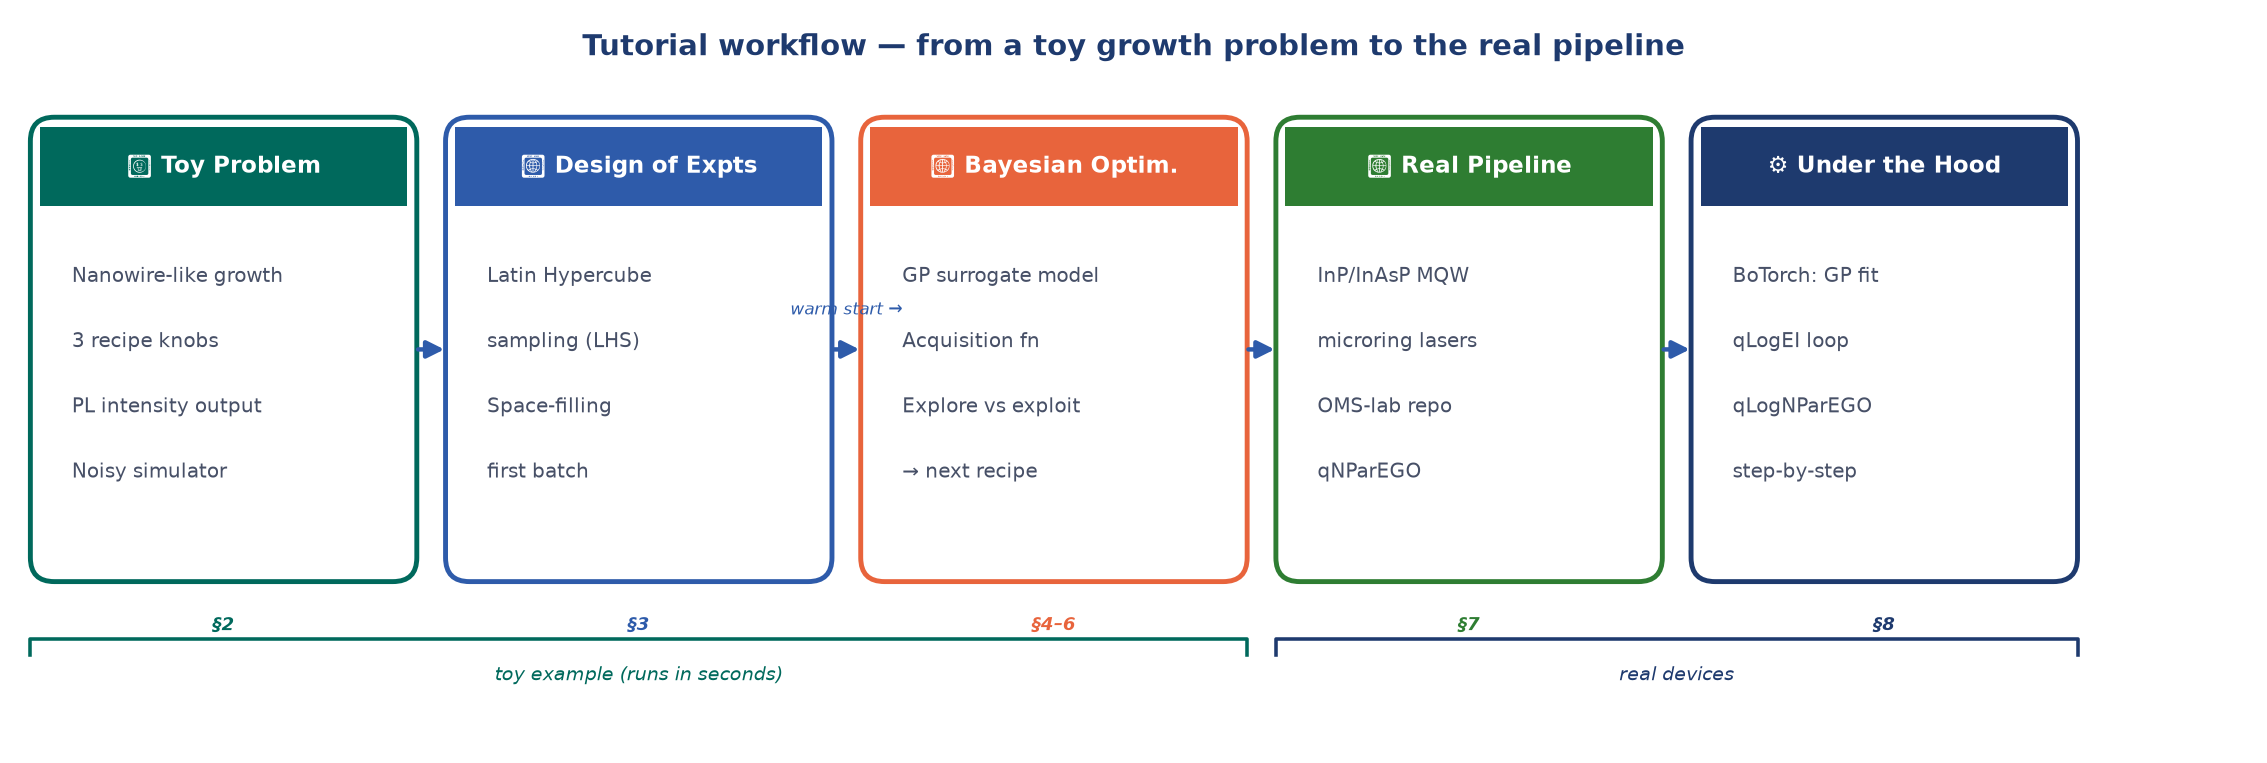

<div style="text-align:center;font-family:'Trebuchet MS',sans-serif;
            font-size:12px;color:#475067;margin-top:6px;">
<i>The five steps of this tutorial — the first three use a fast toy simulator;
the last two connect to the real OMS-lab pipeline.</i>
</div>

---
## 📦 Section 0 · Setup

<div style="background:#FFF3CD;border-left:5px solid #E8643C;
            padding:14px 18px;border-radius:6px;
            font-family:'Trebuchet MS',sans-serif;">
<b>Run this cell once.</b><br><br>
It installs the required packages and then <b>automatically restarts the
Colab runtime</b> so the pinned numpy loads cleanly.<br><br>
After the restart you will see a message like
<i>"Your session crashed"</i> or <i>"Runtime restarted"</i> — <b>that is expected</b>.<br><br>
Then just do <b>Runtime → Run all</b> and every cell will run without errors.
<br><br>
<b>Why the version pins?</b><br>
&nbsp;· <code>numpy&lt;2</code> — numpy 2.x changes binary layout; BoTorch/torch break silently.<br>
&nbsp;· <code>pandas&lt;2.3</code> — pandas 3.0 Copy-on-Write makes Ax's internal arrays
read-only, causing a <code>ValueError</code> mid-optimization.
</div>


In [ ]:
# ── Install pinned dependencies, then auto-restart the runtime ───────────────
# The restart is REQUIRED: Colab pre-loads numpy, and the pinned version
# won't take effect until a fresh kernel loads it from scratch.
import importlib, subprocess, sys, os

def _need_install():
    """Return True if any required package is missing or wrong version."""
    try:
        import numpy as np
        if int(np.__version__.split(".")[0]) >= 2:
            return True          # numpy 2.x is incompatible
        import pandas as pd
        if int(pd.__version__.split(".")[0]) >= 3:
            return True          # pandas 3.x breaks Ax winsorization
        import ax                # will raise if missing
        return False
    except Exception:
        return True

if _need_install():
    print("Installing packages — this takes ~60 seconds on first run...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "ax-platform==0.5.0", "botorch==0.13.0", "numpy<2", "pandas<2.3"
    ])
    print("Done! Restarting runtime so the pinned numpy loads cleanly...")
    os.kill(os.getpid(), 9)   # hard-kill → Colab auto-restarts the kernel
else:
    print("All packages already at correct versions — no restart needed.")
    print("You can run the rest of the notebook now.")


---
## 🧭 Section 1 · What is Bayesian Optimization?

<div style="background:#EEF3FB;border-radius:10px;padding:20px 24px;
            font-family:'Trebuchet MS',sans-serif;line-height:1.7;">

### The problem in one sentence
You want the best growth recipe. Each experiment is slow and expensive.
You cannot afford to search the whole space — so you need to be *smart* about
which recipe to try next.

### What BO does
BO keeps a **probabilistic model** ("surrogate") of the recipe→performance map
and uses it to pick the most informative next experiment every time.

<table style="width:100%;border-collapse:collapse;margin-top:8px;">
<tr style="background:#1E3A6E;color:white;font-weight:bold;">
  <td style="padding:8px 14px;border-radius:5px 0 0 0;">Step</td>
  <td style="padding:8px 14px;">What happens</td>
  <td style="padding:8px 14px;border-radius:0 5px 0 0;">In plain words</td>
</tr>
<tr style="background:#f4f7fd;">
  <td style="padding:8px 14px;font-weight:bold;color:#1E3A6E;">① Propose</td>
  <td style="padding:8px 14px;">Acquisition function scores all untried recipes</td>
  <td style="padding:8px 14px;color:#475067;">"Which recipe would teach us the most?"</td>
</tr>
<tr>
  <td style="padding:8px 14px;font-weight:bold;color:#E8643C;">② Run</td>
  <td style="padding:8px 14px;">Grow the device, measure the result</td>
  <td style="padding:8px 14px;color:#475067;">One real (or simulated) experiment</td>
</tr>
<tr style="background:#f4f7fd;">
  <td style="padding:8px 14px;font-weight:bold;color:#1E3A6E;">③ Update</td>
  <td style="padding:8px 14px;">Gaussian process surrogate is refitted</td>
  <td style="padding:8px 14px;color:#475067;">"Now I know a bit more about the landscape"</td>
</tr>
<tr>
  <td style="padding:8px 14px;font-weight:bold;color:#475067;">④ Repeat</td>
  <td style="padding:8px 14px;">Until budget is spent</td>
  <td style="padding:8px 14px;color:#475067;">Each run is smarter than the last</td>
</tr>
</table>
</div>

<br>

<div style="text-align:center;">
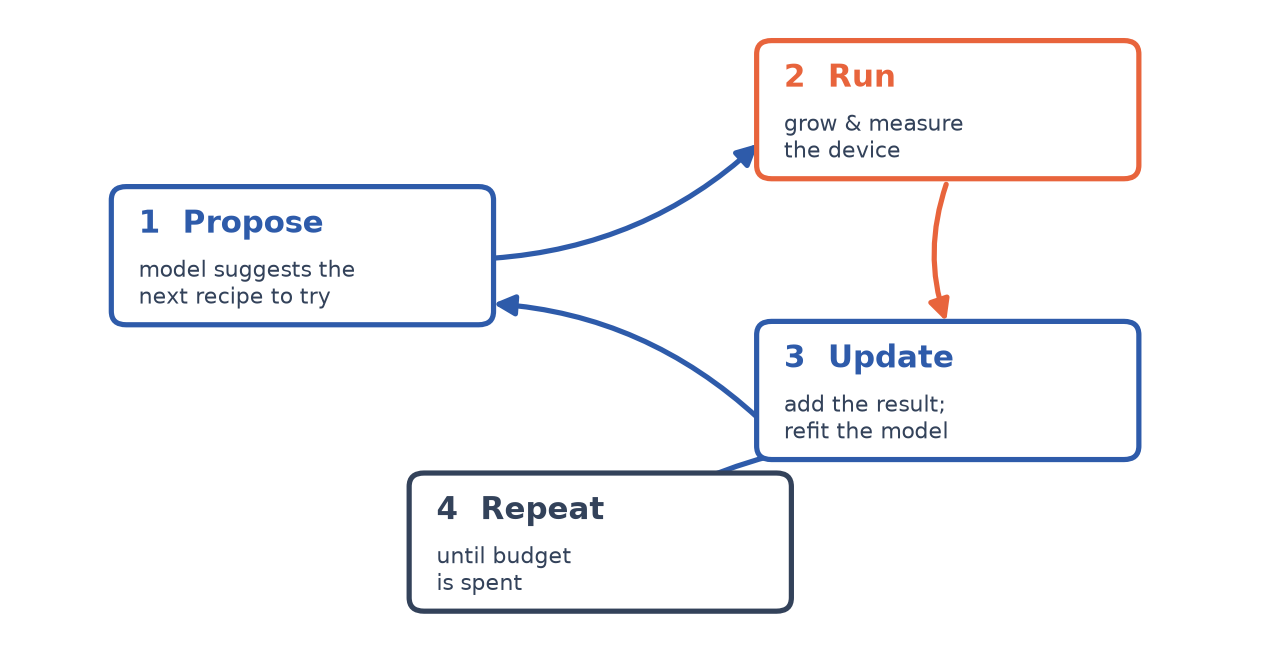
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>The BO loop: the model proposes a recipe → you grow and measure → the model updates → repeat.</i>
</div>
</div>

### Explore vs exploit

The surrogate model predicts performance *and* its own uncertainty.
The acquisition function rewards recipes that look good **and** regions
the model knows little about — this balance is why BO beats random search
in so few experiments.

<div style="text-align:center;margin-top:10px;">
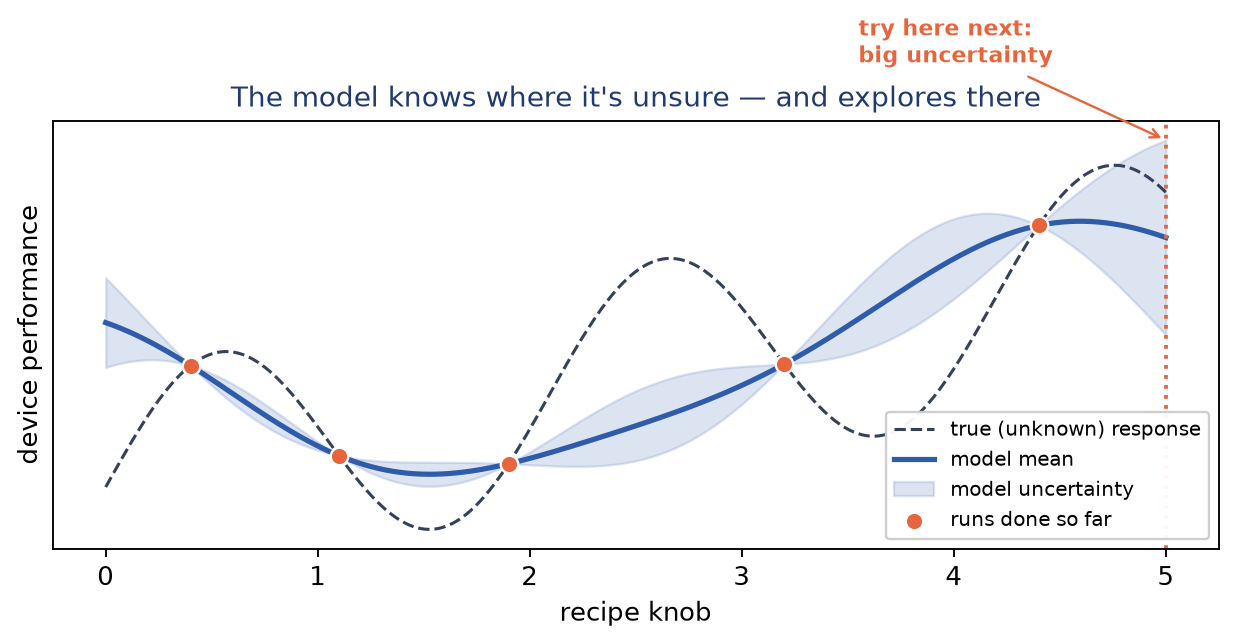
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>The model knows where it is uncertain (wide blue band) and explores there.
Coral dots = experiments run so far. Dashed = true response (unknown to BO).</i>
</div>
</div>

### Pareto front *(multi-objective only)*
When two goals conflict there is no single "best" — instead there is a
**Pareto front**: the set of recipes where you cannot improve one goal
without hurting the other. Section 6 covers this in detail.

---
## 🧪 Section 2 · The toy growth problem

To keep everything fast and free we use a **simulator** instead of a real
MOVPE system. The simulator represents a generic III-V nanowire-like
epitaxial growth where three knobs control the outcome.
This could be a nanowire, a quantum dot ensemble, a thin film —
any structure where PL intensity and emission wavelength matter.
In Section 7 we connect this to the actual **InP/InAsP MQW microring laser**
data from the OMS-lab.

| Knob | What it represents | Range |
|---|---|---|
| `growth_temp` | Growth temperature | 480–560 °C |
| `v_iii_ratio` | Group-V / group-III precursor flow | 5–50 |
| `radius` | Device lateral dimension (e.g. wire/ring radius) | 2–10 µm |

| Output | We want it… | Why |
|---|---|---|
| **PL intensity** (a.u.) | **HIGH** | Device brightness |
| **Emission wavelength** (nm) | **Close to 1310 nm** | O-band telecom target |

> **The key tension:** the brightest recipe emits near ~1348 nm.
> Hitting 1310 nm forces a different recipe — you can't win both at once.
> This is what makes multi-objective BO necessary.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

# ── THE SIMULATOR ────────────────────────────────────────────────────────────
# Replace this function with your real measurement to apply BO to your own system.
# Everything else in the notebook stays the same.
def device_response(temp, v_iii, radius, noise=True, rng=np.random):
    t = (temp   - 480) / 80.0   # rescale to ~[0,1] for readability
    v = (v_iii  -   5) / 45.0
    r = (radius -   2) /  8.0

    # PL intensity: smooth hill peaking at high-T, mid V/III, mid radius
    pl = 100 * np.exp(
        -((t - 0.7)**2) / 0.08
        -((v - 0.5)**2) / 0.15
        -((r - 0.55)**2) / 0.25)

    # Emission wavelength rises with T, falls with V/III, rises with radius.
    # PL-optimal recipe emits ~1348 nm — so hitting 1310 nm costs brightness.
    wl = 1290 + 90*t - 30*v + 25*r

    if noise:
        pl += rng.normal(0, 3.0)   # device-to-device scatter
        wl += rng.normal(0, 2.0)
    return float(max(pl, 0.0)), float(wl)

# ── VISUALISE THE LANDSCAPE ───────────────────────────────────────────────────
T = np.linspace(480, 560, 120)
V = np.linspace(5,   50,  120)
TT, VV = np.meshgrid(T, V)
PL = np.array([[device_response(tt, vv, 6.0, noise=False)[0] for tt in T] for vv in V])
WL = np.array([[device_response(tt, vv, 6.0, noise=False)[1] for tt in T] for vv in V])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
c1 = ax1.contourf(TT, VV, PL, levels=20, cmap="viridis")
ax1.contour(TT, VV, PL, levels=8, colors="white", linewidths=0.4, alpha=0.5)
ax1.set_xlabel("growth temperature (°C)"); ax1.set_ylabel("V/III ratio")
ax1.set_title("PL intensity landscape (radius = 6 µm)")
plt.colorbar(c1, ax=ax1, label="PL (a.u.)")

c2 = ax2.contourf(TT, VV, WL, levels=20, cmap="RdYlBu_r")
ax2.contour(TT, VV, WL, levels=8, colors="white", linewidths=0.4, alpha=0.5)
ax2.set_xlabel("growth temperature (°C)"); ax2.set_ylabel("V/III ratio")
ax2.set_title("Emission wavelength (radius = 6 µm)")
plt.colorbar(c2, ax=ax2, label="wavelength (nm)")

plt.suptitle("BO never sees these maps — it learns them from the runs it chooses",
             fontsize=11, style="italic", color="#475067", y=1.01)
plt.tight_layout(); plt.show()

print("PL optimum is near T~537 C, V/III~27, radius~6 um")
print("At that recipe, wavelength ~", round(device_response(537, 27, 6, noise=False)[1]), "nm")
print("Hitting 1310 nm target requires lower T / higher V/III -> PL drops")

### 🔬 Try a growth recipe by hand

Drag the sliders, re-run, and try to score above 70 on both metrics at once.
The difficulty you feel is exactly the problem BO is designed to solve.

In [ ]:
#@markdown #### Drag the knobs, then press ▶
growth_temp = 530   #@param {type:"slider", min:480, max:560, step:2}
v_iii_ratio = 28    #@param {type:"slider", min:5,   max:50,  step:1}
radius      = 6.0   #@param {type:"slider", min:2.0, max:10.0,step:0.5}

pl, wl = device_response(growth_temp, v_iii_ratio, radius, noise=False)
target = 1310

score_pl  = min(100, round(pl))
score_wl  = max(0, round(100 - 2*abs(wl - target)))

bar_pl = "█" * (score_pl  // 5) + "░" * (20 - score_pl  // 5)
bar_wl = "█" * (score_wl  // 5) + "░" * (20 - score_wl  // 5)

print(f"Recipe:  T = {growth_temp} °C   V/III = {v_iii_ratio}   radius = {radius} µm")
print(f"─────────────────────────────────────────────────────")
print(f"PL intensity     = {pl:5.1f} a.u.   {'🟢 bright' if pl>70 else '🟡 ok' if pl>40 else '🔴 dim'}")
print(f"Emission λ       = {wl:5.0f} nm    target 1310 nm  |Δλ| = {abs(wl-target):.0f} nm")
print(f"─────────────────────────────────────────────────────")
print(f"PL score   [{bar_pl}] {score_pl}/100")
print(f"Wavel. score [{bar_wl}] {score_wl}/100")
print(f"Combined   = {(score_pl+score_wl)//2}/100  ← try to beat 70!")

---
## 📐 Section 3 · Design of Experiments — a smart first batch

Before BO can be clever it needs *some* data. Where should those first
runs go?

<div style="display:flex;gap:14px;margin:10px 0;font-family:'Trebuchet MS',sans-serif;">
  <div style="flex:1;background:#fdecea;border-radius:8px;padding:12px 15px;">
    <b style="color:#c0392b;">❌ Random</b><br>
    Quick but points can clump — whole regions stay unexplored.
  </div>
  <div style="flex:1;background:#fef9e7;border-radius:8px;padding:12px 15px;">
    <b style="color:#b7770d;">⚠️ Full-factorial grid</b><br>
    Even but explodes: 5 levels × 3 knobs = <b>125 runs</b>.
  </div>
  <div style="flex:1;background:#eafaf1;border-radius:8px;padding:12px 15px;">
    <b style="color:#1E3A6E;">✅ Latin Hypercube (LHS)</b><br>
    Slices each knob range evenly — maximum coverage, minimum runs.
    <b>What the OMS-lab repo uses.</b>
  </div>
</div>

<div style="text-align:center;margin:14px 0;">
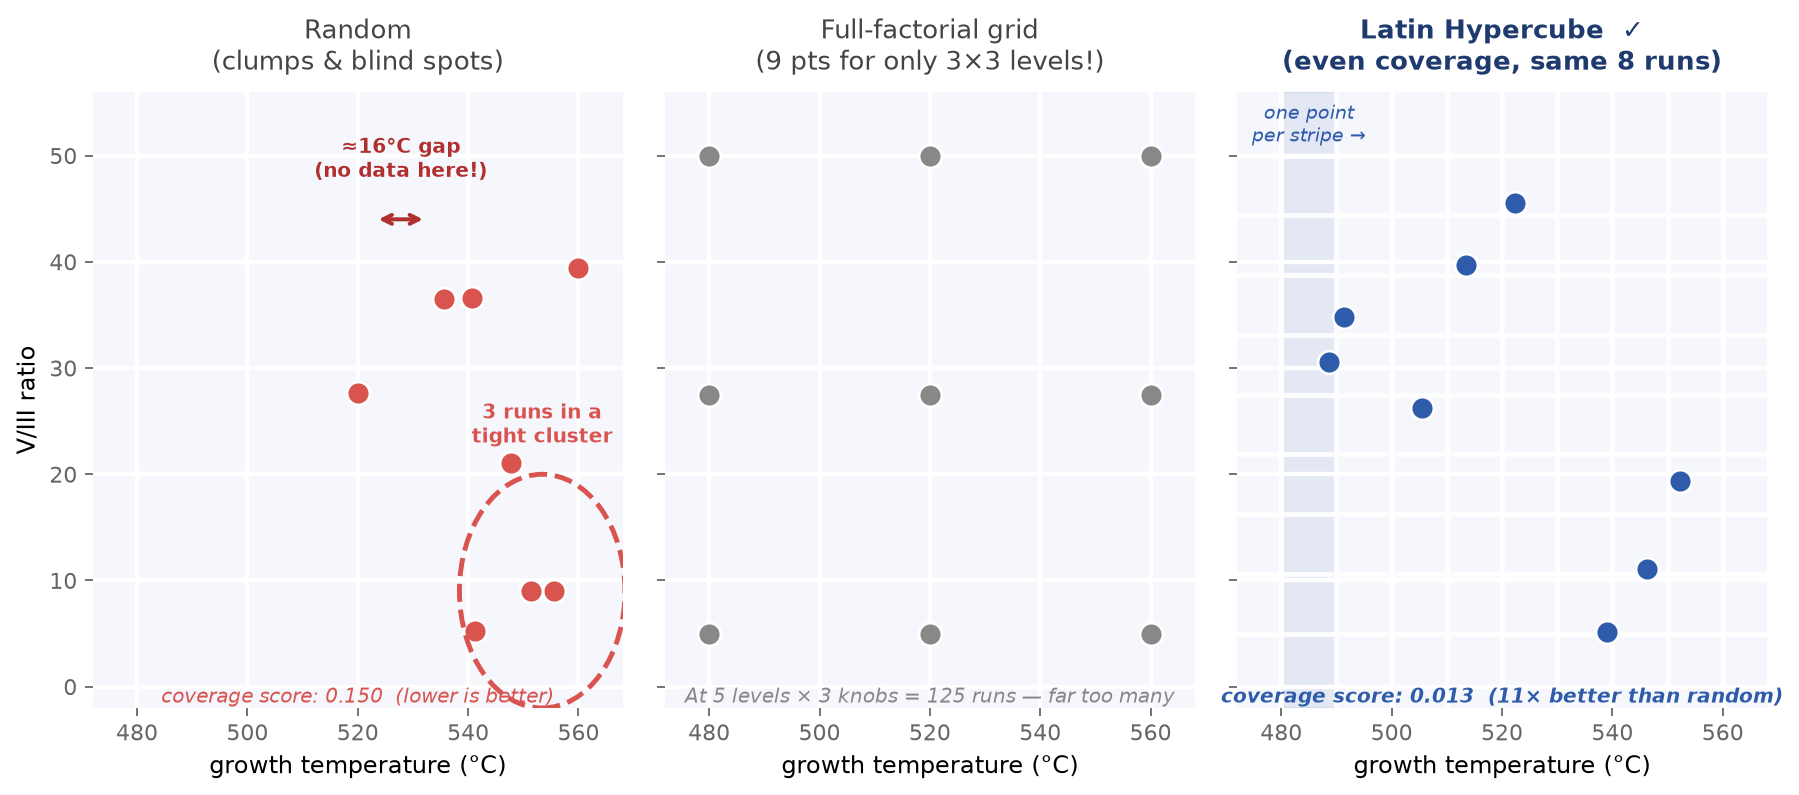
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>Same number of runs (8), three strategies. LHS (right, blue) covers the space evenly — random (left) clumps.</i>
</div>
</div>

In [ ]:
#@markdown #### ⚙️ DoE settings
n_doe    = 8  #@param {type:"slider", min:4, max:20, step:1}
doe_seed = 0  #@param {type:"integer"}
print(f"Latin-Hypercube DoE: {n_doe} runs, seed {doe_seed}")

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

lows  = np.array([480.0,  5.0, 2.0])
highs = np.array([560.0, 50.0, 10.0])
names = ["growth_temp", "v_iii_ratio", "radius"]

# Build LHS design
unit_pts = qmc.LatinHypercube(d=3, seed=doe_seed).random(n=n_doe)
design   = qmc.scale(unit_pts, lows, highs)

# Run each recipe through the simulator
rng_doe = np.random.RandomState(doe_seed)
rows = []
for x in design:
    pl, wl = device_response(*x, rng=rng_doe)
    rows.append([*x, pl, wl])
doe_df = pd.DataFrame(rows, columns=names + ["pl_intensity", "wavelength"])

print("DoE starting dataset:")
display(doe_df.round(1))

# Coverage score
rand_unit = np.random.RandomState(doe_seed).random((n_doe, 3))
print("\nCoverage score (lower = more even):")
print("  LHS    =", round(qmc.discrepancy(unit_pts), 4), " <- better")
print("  Random =", round(qmc.discrepancy(rand_unit), 4))

### ▶️ Warm start: hand the DoE batch to BO

The DoE runs become the optimizer's **starting data** — BO immediately
proposes informed recipes rather than wasting early trials on random probing.
This is exactly the DoE → BO handoff the `Microring_MOBO` pipeline uses.

<div style="text-align:center;margin:12px 0;">
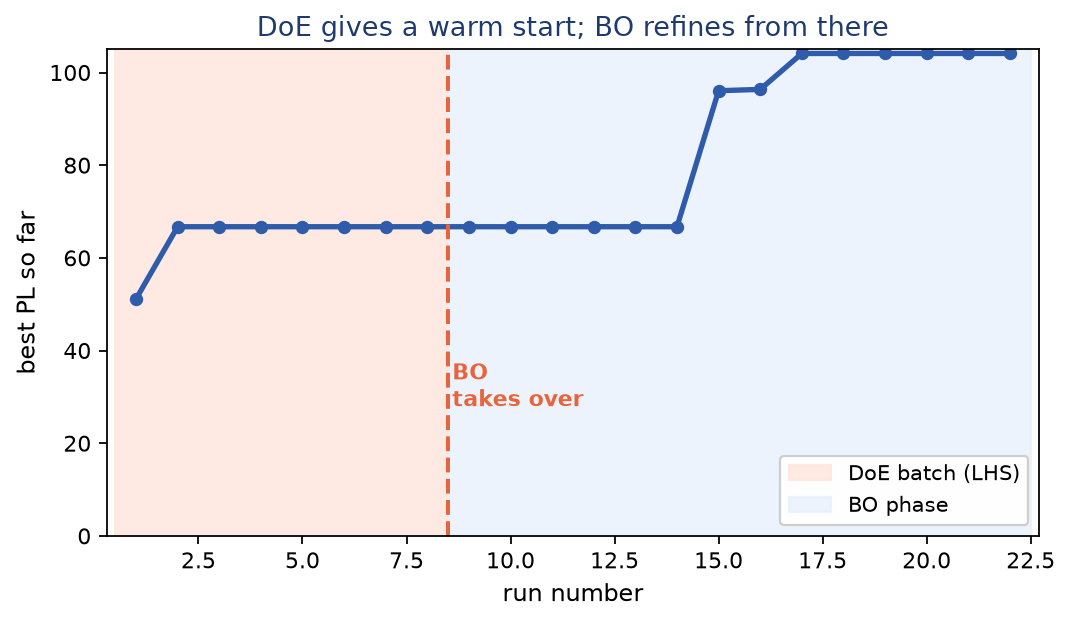
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>Salmon = DoE phase. Blue = BO phase. The dashed line is where BO takes over from the LHS batch.</i>
</div>
</div>

In [ ]:
#@markdown #### Extra BO runs after the DoE batch:
n_bo_after_doe = 12  #@param {type:"slider", min:4, max:30, step:1}

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_ws = np.random.RandomState(doe_seed)
ax_ws  = AxClient(verbose_logging=False, random_seed=doe_seed)
ax_ws.create_experiment(
    name="doe_warmstart",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "radius",      "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={"pl_intensity": ObjectiveProperties(minimize=False)},
)

# Warm start: attach DoE recipes we already ran
for row in design:
    temp, v_iii, rad = float(row[0]), float(row[1]), float(row[2])
    p = {"growth_temp": temp, "v_iii_ratio": v_iii, "radius": rad}
    _, idx = ax_ws.attach_trial(parameters=p)
    pl, _ = device_response(temp, v_iii, rad, rng=rng_ws)
    ax_ws.complete_trial(trial_index=idx, raw_data={"pl_intensity": (pl, None)})

# BO takes over
for _ in range(n_bo_after_doe):
    p, idx = ax_ws.get_next_trial()
    pl, _ = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["radius"], rng=rng_ws)
    ax_ws.complete_trial(trial_index=idx, raw_data={"pl_intensity": (pl, None)})

df_ws   = ax_ws.get_trials_data_frame().sort_values("trial_index")
best_ws = df_ws["pl_intensity"].cummax().values

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_betweenx([0,105],[0.5],[n_doe+0.5],color="#ffe7df",alpha=0.85,label="DoE batch (LHS)")
ax.fill_betweenx([0,105],[n_doe+0.5],[len(best_ws)+0.5],color="#e8f0fc",alpha=0.75,label="BO phase")
ax.plot(range(1,len(best_ws)+1), best_ws, "-o", color="#2E5BAA", lw=2.4, ms=5)
ax.axvline(n_doe+0.5, color="#E8643C", lw=1.8, ls="--")
ax.annotate("BO takes over", (n_doe+0.7,22), fontsize=10,
            color="#E8643C", fontweight="bold")
ax.set_xlim(0.3, len(best_ws)+0.7); ax.set_ylim(0,105)
ax.set_xlabel("run number"); ax.set_ylabel("best PL intensity so far")
ax.set_title("DoE gives a warm start; BO refines from there")
ax.legend(fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()

bp, (m, _) = ax_ws.get_best_parameters()
print("Best after DoE + BO:")
print("  T=%.0f C  V/III=%.0f  radius=%.1f um" % (
    bp["growth_temp"], bp["v_iii_ratio"], bp["radius"]))
print("  Predicted PL = %.1f a.u." % m["pl_intensity"])

> 💬 **Try it:** set `n_doe=4` and `n_bo_after_doe=4` — can BO still converge?
> What's the minimum total budget to get PL > 90?

---
## 🧩 Section 4 · Honegumi — your BO template in one click

[**Honegumi**](https://honegumi.readthedocs.io) is an interactive
template generator built on the Ax platform. Toggle the options below
in the grid, copy the generated script, and replace only the parameters,
objectives, and the function that runs your experiment.

<div style="text-align:center;margin:14px 0;">
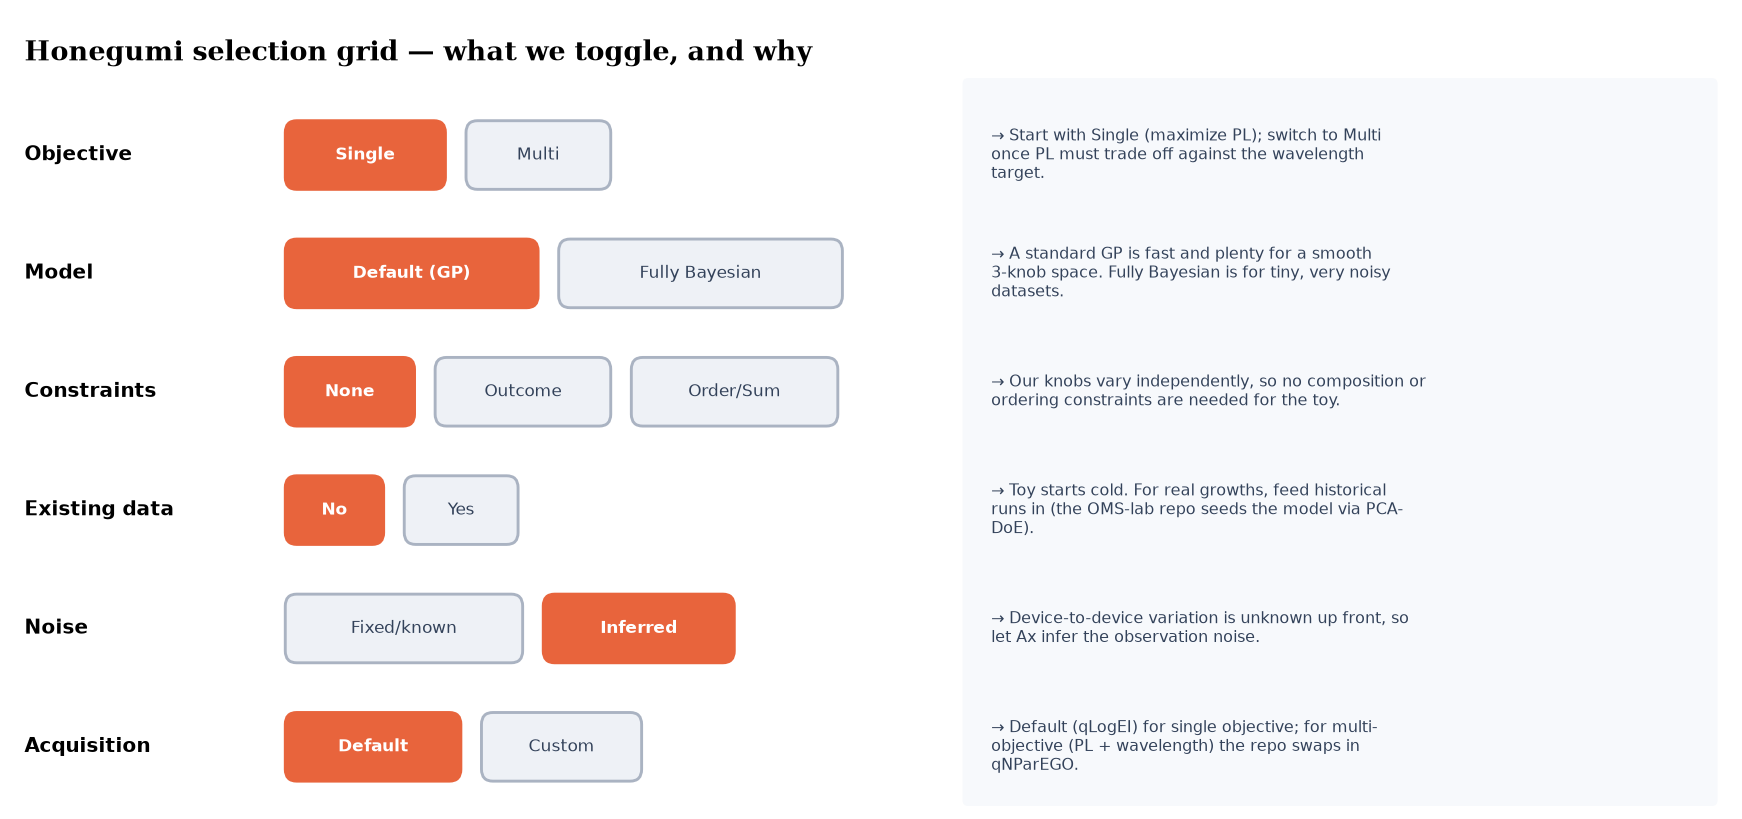
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>Highlighted (coral) = the choices we make for this tutorial, with reasoning on the right.
Visit honegumi.readthedocs.io to generate your own script.</i>
</div>
</div>

The single most important toggle: **Objective → Single vs Multi**.
We run both — single-objective first (just PL), then multi-objective
(PL + wavelength target).

---
## 🎯 Section 5 · Single-objective BO — maximize PL

Goal: get the brightest device, ignoring wavelength for now.
The code below is essentially what Honegumi generates.

The BO loop is three lines:
```python
params = ax_client.get_next_trial()      # model proposes the next recipe
result = run_experiment(params)          # measure (here: simulator)
ax_client.complete_trial(result)         # feed the result back
```

<div style="text-align:center;margin:14px 0;">
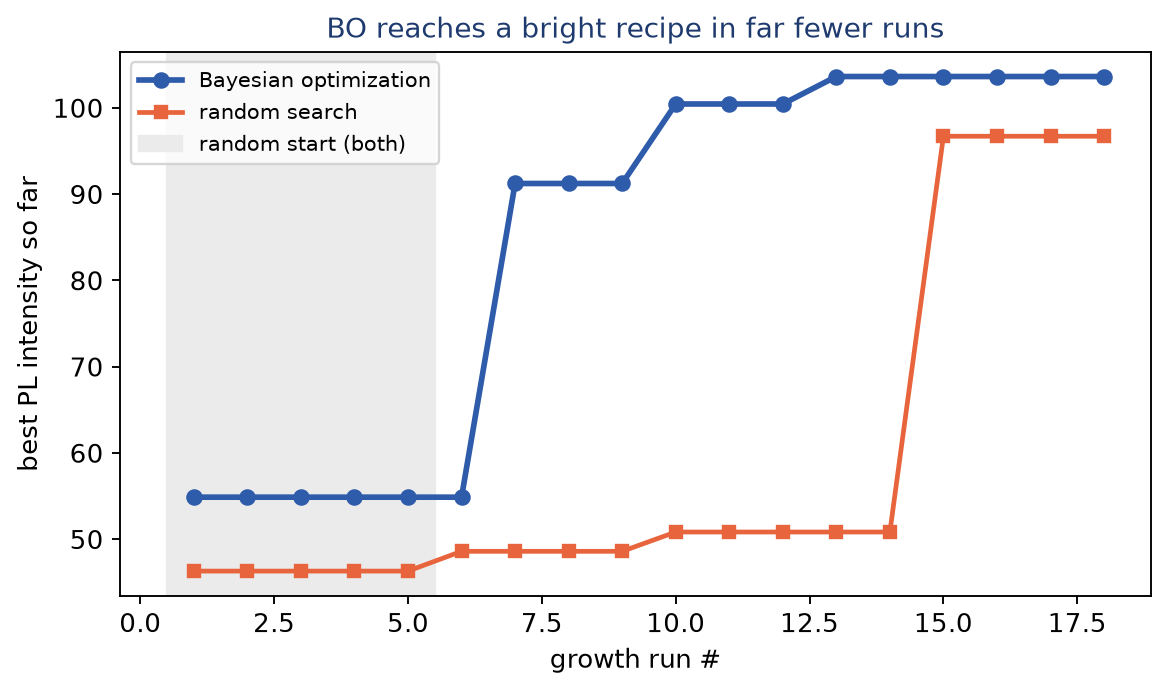
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>BO (blue) reaches the bright recipe far faster than random search (coral).
Shaded region = quasi-random Sobol initialization runs.</i>
</div>
</div>

In [ ]:
#@markdown #### ⚙️ Single-objective settings
n_trials    = 18  #@param {type:"slider", min:8, max:40, step:1}
random_seed =  0  #@param {type:"integer"}
print(f"{n_trials} trials, seed {random_seed}")

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_so = np.random.RandomState(random_seed)
ax_so  = AxClient(verbose_logging=False, random_seed=random_seed)
ax_so.create_experiment(
    name="single_obj_bo",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "radius",      "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={"pl_intensity": ObjectiveProperties(minimize=False)},
)

def eval_so(p):
    pl, _ = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["radius"], rng=rng_so)
    return {"pl_intensity": (pl, None)}

for i in range(n_trials):
    params, idx = ax_so.get_next_trial()
    ax_so.complete_trial(trial_index=idx, raw_data=eval_so(params))

best_p, (means, _) = ax_so.get_best_parameters()
print("Best recipe found:")
for k, v in best_p.items():
    print("  %-15s = %.1f" % (k, v))
print("  Predicted PL = %.1f a.u." % means["pl_intensity"])

# Plot convergence vs random baseline
rng_rnd = np.random.RandomState(random_seed + 99)
rnd_best, cur = -1, []
for _ in range(n_trials):
    pl, _ = device_response(
        rng_rnd.uniform(480,560), rng_rnd.uniform(5,50),
        rng_rnd.uniform(2,10), rng=rng_rnd)
    rnd_best = max(rnd_best, pl); cur.append(rnd_best)

df_so  = ax_so.get_trials_data_frame().sort_values("trial_index")
bo_best = df_so["pl_intensity"].cummax().values

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,len(bo_best)+1), bo_best, "-o",
        color="#2E5BAA", lw=2.4, label="Bayesian optimization")
ax.plot(range(1,len(cur)+1), cur, "-s",
        color="#E8643C", lw=2.0, ms=5, alpha=0.8, label="random search")
ax.axvspan(0.5, 5.5, color="0.92", label="Sobol init (both)")
ax.set_xlabel("growth run #"); ax.set_ylabel("best PL intensity so far")
ax.set_title("BO finds the bright recipe in far fewer runs than random")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

> 💬 **Try it:** change `random_seed` to 1, 2, 3 — does BO always beat random?
> What is the minimum `n_trials` where BO reliably reaches PL > 90?

---
## 🎯🎯 Section 6 · Multi-objective BO — PL *and* target wavelength

Single-objective gave us the brightest device, but it emits at ~1348 nm —
not the O-band target of 1310 nm. We now optimize **both** simultaneously.

There is no single "best" — instead there is a **Pareto front**:
the set of recipes where you cannot improve PL without moving the wavelength
further from target, and vice versa.

<div style="text-align:center;margin:14px 0;">
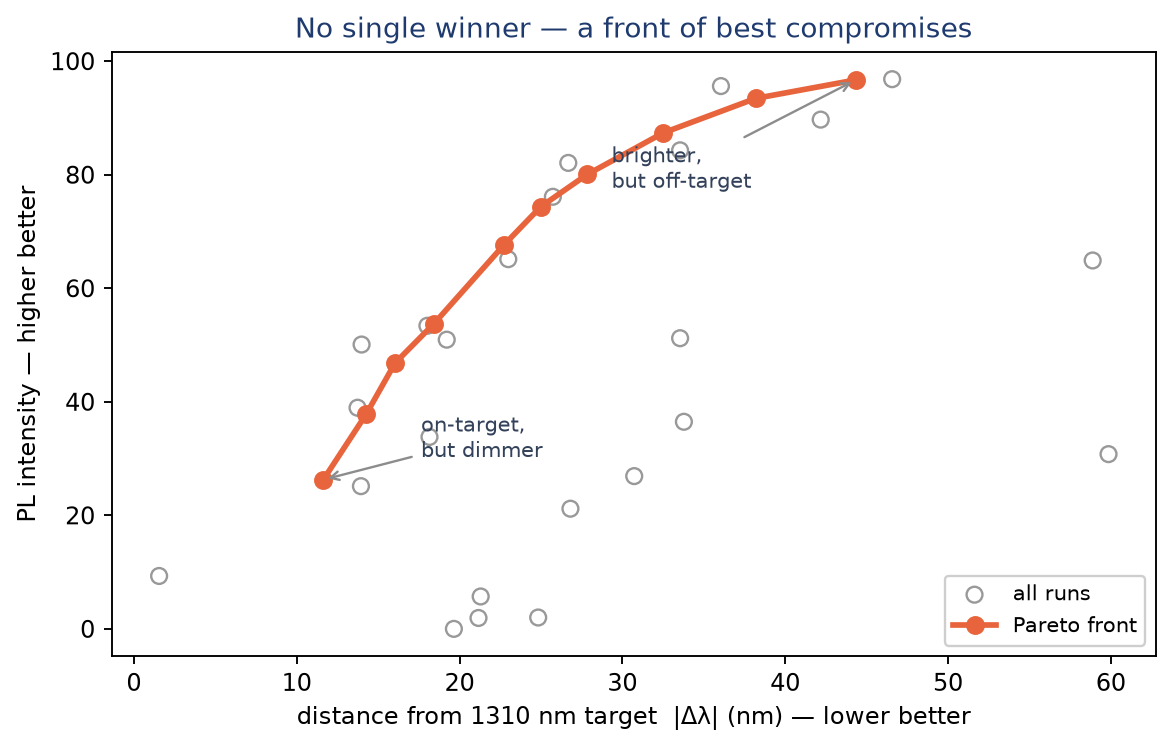
<div style="font-size:12px;color:#475067;font-family:'Trebuchet MS',sans-serif;margin-top:4px;">
<i>The coral Pareto front spans "bright but off-target" to "on-target but dimmer".
Every point on the front is a best possible compromise — which one to pick
is a design decision, not an optimization one.</i>
</div>
</div>

Use the slider to move the wavelength target and watch the front shift.

In [ ]:
#@markdown #### ⚙️ Multi-objective settings
target_wavelength = 1310  #@param {type:"slider", min:1250, max:1380, step:5}
n_trials_mo  = 24         #@param {type:"slider", min:10, max:50, step:1}
seed_mo      =  2         #@param {type:"integer"}
print(f"Target = {target_wavelength} nm  |  {n_trials_mo} runs  |  seed {seed_mo}")

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_mo = np.random.RandomState(seed_mo)
ax_mo  = AxClient(verbose_logging=False, random_seed=seed_mo)
ax_mo.create_experiment(
    name="multi_obj_bo",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "radius",      "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={
        "pl_intensity":      ObjectiveProperties(minimize=False, threshold=20.0),
        "wavelength_offset": ObjectiveProperties(minimize=True,  threshold=60.0),
    },
)

def eval_mo(p):
    pl, wl = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["radius"], rng=rng_mo)
    return {"pl_intensity":      (pl, None),
            "wavelength_offset": (abs(wl - target_wavelength), None)}

for i in range(n_trials_mo):
    params, idx = ax_mo.get_next_trial()
    ax_mo.complete_trial(trial_index=idx, raw_data=eval_mo(params))

pareto = ax_mo.get_pareto_optimal_parameters()
df_mo  = ax_mo.get_trials_data_frame()

print("%d Pareto-optimal recipes (target = %d nm):" % (len(pareto), target_wavelength))
print("  %-7s  %-10s  %-7s  %-6s  %-7s" % ("PL","wavelength |Δλ|","T (C)","V/III","radius"))
print("  " + "-"*46)
for _, (p, (m, _)) in sorted(pareto.items(),
                               key=lambda x: -x[1][1][0]["pl_intensity"]):
    print("  %-7.1f  %-10.1f  %-7.0f  %-6.0f  %-7.1f" % (
        m["pl_intensity"], m["wavelength_offset"],
        p["growth_temp"], p["v_iii_ratio"], p["radius"]))

pf = sorted([(m["wavelength_offset"], m["pl_intensity"])
             for _, (p, (m, _)) in pareto.items()])
pf_off, pf_pl = zip(*pf)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_mo["wavelength_offset"], df_mo["pl_intensity"],
           facecolors="none", edgecolors="0.6", s=50, label="all runs")
ax.plot(pf_off, pf_pl, "-o", color="#E8643C", lw=2.4, ms=7,
        label="Pareto front")
ax.annotate("brighter,\nbut off-target",
            (pf_off[-1], pf_pl[-1]), xytext=(pf_off[-1]-14, pf_pl[-1]-16),
            fontsize=9, color="#475067",
            arrowprops=dict(arrowstyle="->", color="0.6"))
ax.annotate("on-target,\nbut dimmer",
            (pf_off[0], pf_pl[0]), xytext=(pf_off[0]+5, pf_pl[0]+4),
            fontsize=9, color="#475067",
            arrowprops=dict(arrowstyle="->", color="0.6"))
ax.set_xlabel("distance from %d nm target  |Δλ| (nm)" % target_wavelength)
ax.set_ylabel("PL intensity")
ax.set_title("No single winner — a front of best compromises")
ax.legend(fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()

> 💬 **Try it:**
> - Move `target_wavelength` to 1290 or 1350 nm — watch the Pareto front shift.
> - What happens to the front if you increase `n_trials_mo` to 40?
> - Can you find a single recipe that scores ≥ 70 PL *and* |Δλ| < 20 nm?

---
## 🔬 Section 7 · From the toy to the real OMS-lab pipeline

Everything you just ran is a miniature of a real published study.

<div style="background:linear-gradient(135deg,#1E3A6E,#2E5BAA);
            border-radius:10px;padding:20px 24px;color:white;
            font-family:'Trebuchet MS',sans-serif;margin:12px 0;">
  <div style="font-size:14px;color:#CFE0FA;margin-bottom:6px;">
    The companion repository:
  </div>
  <div style="font-size:21px;font-weight:bold;">
    <a href="https://github.com/OMS-lab/Microring_MOBO"
       style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
  </div>
  <div style="margin-top:10px;font-size:14px;color:#CFE0FA;line-height:1.6;">
    Multi-objective Bayesian optimization for bottom-up grown
    <b style="color:white;">InP/InAsP MQW microring lasers</b> —
    jointly optimizing emission wavelength, lasing threshold, and yield.
    (Athavale et al., <i>ACS Photonics</i>)
  </div>
</div>

| This notebook | Real `Microring_MOBO` pipeline |
|---|---|
| Nanowire-like toy simulator | Measured InP/InAsP MQW device data |
| 3 generic knobs | Real MOVPE growth + ring-geometry parameters |
| Small LHS warm start | PCA-enhanced DoE + Latin-Hypercube sampling |
| Ax default acquisition | `qNParEGO` in BoTorch |
| PL + wavelength | Wavelength + lasing threshold + yield |

To run it yourself: clone the repo, open `BO with DoE.ipynb`,
and swap in your dataset, bounds, and objectives.

---
## ⚙️ Section 8 · Under the hood — BoTorch

Ax and the OMS-lab repo sit on top of **BoTorch**.
This section does one round by hand so you can see what Ax hides:

1. **Fit a Gaussian process** to the data so far.
2. **Maximize an acquisition function** to pick the next recipe.

We show a single-objective loop with `qLogExpectedImprovement`,
then one step of **`qLogNParEGO`** — the modern form of the acquisition
the OMS-lab repo uses for its multi-objective search.

> You don't need to understand every line.
> The goal is to see the **GP fit → acquisition maximize** pattern.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import torch
from torch.quasirandom import SobolEngine
from botorch.models import SingleTaskGP, ModelListGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood, SumMarginalLogLikelihood
from botorch.acquisition.logei import qLogExpectedImprovement
from botorch.acquisition.multi_objective.parego import qLogNParEGO
from botorch.optim import optimize_acqf
from botorch.utils.transforms import normalize, unnormalize
from botorch.sampling.normal import SobolQMCNormalSampler

torch.manual_seed(0)
tkw    = {"dtype": torch.double}
bounds = torch.tensor([[480., 5., 2.], [560., 50., 10.]], **tkw)
unit   = torch.stack([torch.zeros(3, **tkw), torch.ones(3, **tkw)])

def device_torch(X):
    t=(X[:,0]-480)/80; v=(X[:,1]-5)/45; r=(X[:,2]-2)/8
    pl  = 100*torch.exp(-((t-0.7)**2)/0.08 - ((v-0.5)**2)/0.15 - ((r-0.55)**2)/0.25)
    wl  = 1290 + 90*t - 30*v + 25*r
    return torch.stack([pl, wl], dim=-1)

X = unnormalize(SobolEngine(3, scramble=True, seed=0).draw(6).to(**tkw), bounds)
Y = device_torch(X)

# ── Single-objective loop: maximize PL ──────────────────────────────────────
for step in range(8):
    Xn = normalize(X, bounds)
    y  = Y[:, 0:1]
    ys = (y - y.mean()) / y.std()           # standardise for the GP

    gp  = SingleTaskGP(Xn, ys)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)                   # train the GP on data so far

    acqf = qLogExpectedImprovement(model=gp, best_f=ys.max())
    cand, _ = optimize_acqf(acqf, bounds=unit, q=1,
                             num_restarts=5, raw_samples=64)
    Xnew = unnormalize(cand, bounds)
    X = torch.cat([X, Xnew])
    Y = torch.cat([Y, device_torch(Xnew)])

i = int(Y[:, 0].argmax())
print("BoTorch single-objective:")
print("  Best PL = %.1f a.u.  at  T=%.0f C  V/III=%.0f  r=%.1f um" % (
    Y[i,0], X[i,0], X[i,1], X[i,2]))

# ── One qLogNParEGO step (the repo's multi-obj acquisition) ─────────────────
tgt = 1310.0
Ym  = torch.stack([Y[:,0], -(Y[:,1]-tgt).abs()], dim=-1)
Yms = (Ym - Ym.mean(0)) / Ym.std(0)
Xn  = normalize(X, bounds)
mlist = ModelListGP(*[SingleTaskGP(Xn, Yms[:,k:k+1]) for k in range(2)])
fit_gpytorch_mll(SumMarginalLogLikelihood(mlist.likelihood, mlist))
parego = qLogNParEGO(model=mlist, X_baseline=Xn,
                     sampler=SobolQMCNormalSampler(sample_shape=torch.Size([64])))
cand, _ = optimize_acqf(parego, bounds=unit, q=1, num_restarts=5, raw_samples=64)
nxt = unnormalize(cand, bounds).squeeze().tolist()
print("\nqLogNParEGO (the repo acquisition) proposes:")
print("  T=%.1f C  V/III=%.1f  radius=%.1f um" % (nxt[0], nxt[1], nxt[2]))

---
## 🏁 Section 9 · Recap & next steps

<div style="background:linear-gradient(135deg,#1E3A6E 60%,#2E5BAA);
            border-radius:12px;padding:28px 32px;color:white;
            font-family:'Trebuchet MS',sans-serif;">
<div style="display:flex;gap:28px;flex-wrap:wrap;">

<div style="flex:1;min-width:240px;">
<div style="font-size:12px;letter-spacing:3px;color:#CFE0FA;margin-bottom:10px;">
WHAT YOU LEARNED</div>

✅ &nbsp;<b>DoE (LHS)</b> fills the space evenly so BO starts informed, not blind.<br><br>
✅ &nbsp;<b>BO</b> models recipe→performance and proposes the most informative run each time.<br><br>
✅ &nbsp;<b>Single-objective BO</b> finds one best recipe in far fewer runs than random.<br><br>
✅ &nbsp;<b>Multi-objective BO</b> returns a <b>Pareto front</b> of best compromises.<br><br>
✅ &nbsp;The <b>OMS-lab pipeline</b> is exactly this, on real InP/InAsP MQW microrings.
</div>

<div style="flex:1;min-width:240px;">
<div style="font-size:12px;letter-spacing:3px;color:#CFE0FA;margin-bottom:10px;">
TRY THESE NEXT</div>

🔧 &nbsp;Move the wavelength slider to 1290 or 1350 nm.<br><br>
🔧 &nbsp;Add a 4th knob (e.g. growth time) to the parameters list.<br><br>
🔧 &nbsp;Replace <code>device_response</code> with a lookup into your own measured data.<br><br>
🔧 &nbsp;Clone <a href="https://github.com/OMS-lab/Microring_MOBO"
style="color:#E8643C;"><b>Microring_MOBO</b></a> and run <code>BO with DoE.ipynb</code>.
</div>

</div>
<div style="margin-top:22px;border-top:1px solid rgba(255,255,255,0.2);
            padding-top:14px;font-size:13px;color:#CFE0FA;">
<b style="color:white;">Templates:</b>
<a href="https://honegumi.readthedocs.io" style="color:#E8643C;">honegumi.readthedocs.io</a>
&nbsp;·&nbsp;
<b style="color:white;">Real pipeline:</b>
<a href="https://github.com/OMS-lab/Microring_MOBO" style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
</div>
</div>